# Modeling



Imports

In [1]:

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

Loading and preparing data

In [3]:
disease = pd.read_csv("../data/raw/complete_plant_disease_database.csv")
climate = pd.read_csv("../data/raw/complete_plant_study_climate_data.csv")

df = disease.merge(climate, left_on="Obs", right_on="obs")

df = df.dropna(subset=[
    "Incidence",
    "bio01",
    "bio12",
    "Latitude",
    "Longitude",
    "Year",
    "Natural_or_ag",
    "Habitat"
]).copy()

features = [
    "bio01",
    "bio12",
    "Latitude",
    "Longitude",
    "Year",
    "Natural_or_ag",
    "Habitat"
]


X = df[features]

# encode categorical variables
X = pd.get_dummies(
    X,
    columns=["Natural_or_ag", "Habitat"],
    drop_first=True
)

# log-transform target variable
y = np.log1p(df["Incidence"])

X.shape, y.shape

((5903, 9), (5903,))

Feature Selection

In [5]:
# selected features for modeling
features = [
    "bio01",          # mean temperature
    "bio12",          # annual precipitation
    "Latitude",
    "Longitude",
    "Year",
    "Natural_or_ag",
    "Habitat"
]

# create feature matrix
X = df[features]

# encode categorical variables
X = pd.get_dummies(
    X,
    columns=["Natural_or_ag", "Habitat"],
    drop_first=True
)

# log-transform target variable
y = np.log1p(df["Incidence"])

# inspect final feature matrix
print(X.head())
print(X.shape)

        bio01        bio12  Latitude  Longitude  Year  \
0   95.853316   943.493736    45.367      6.029  2008   
1   50.894780  1283.165287    45.393      6.117  2008   
2   46.951686  1317.325816    45.392      6.122  2008   
3   30.425471  1458.278376    45.381      6.148  2008   
4  102.943483   898.312969    45.403      6.083  2008   

   Natural_or_ag_Botanical Garden  Natural_or_ag_Natural  Habitat_Terrestrial  \
0                           False                   True                 True   
1                           False                   True                 True   
2                           False                   True                 True   
3                           False                   True                 True   
4                           False                   True                 True   

   Habitat_Wetland  
0            False  
1            False  
2            False  
3            False  
4            False  
(5903, 9)


Fix float value issue

In [11]:
# Fix Year values like "2011-2012" by taking the first year
df["Year"] = (
    df["Year"]
    .astype(str)
    .str.extract(r"(\d{4})")[0]
)

df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

In [12]:
# Basic cleaning
df = df.dropna(subset=[
    "Incidence",
    "bio01",
    "bio12",
    "Latitude",
    "Longitude",
    "Year",
    "Natural_or_ag",
    "Habitat"
]).copy()

# Fix Year column
df["Year"] = (
    df["Year"]
    .astype(str)
    .str.extract(r"(\d{4})")[0]
)

df["Year"] = pd.to_numeric(df["Year"], errors="coerce")

# Drop rows where Year could not be converted
df = df.dropna(subset=["Year"]).copy()

# Feature selection
features = [
    "bio01",
    "bio12",
    "Latitude",
    "Longitude",
    "Year",
    "Natural_or_ag",
    "Habitat"
]

X = df[features]

# One-hot encode categorical variables
X = pd.get_dummies(
    X,
    columns=["Natural_or_ag", "Habitat"],
    drop_first=True
)

# Make sure all features are numeric
X = X.astype(float)

# Log-transform target
y = np.log1p(df["Incidence"])

Train Test/split 

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Linear Regression

In [14]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

Decission Tree 

In [15]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

Evaluate

In [16]:
from sklearn.metrics import mean_squared_error, r2_score

print("Decision Tree:")
print("MSE:", mean_squared_error(y_test, y_pred_dt))
print("R2:", r2_score(y_test, y_pred_dt))

Decision Tree:
MSE: 0.025229826647289372
R2: 0.3424155970037672


In [17]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree")
print("MSE:", mean_squared_error(y_test, y_pred_dt))
print("R2:", r2_score(y_test, y_pred_dt))

Decision Tree
MSE: 0.025229826647289372
R2: 0.3424155970037672


Random Forest

In [19]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

Nueral Network

Scale Features

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training (small scale)

In [21]:
from sklearn.neural_network import MLPRegressor

nn = MLPRegressor(
    hidden_layer_sizes=(32, 16),   
    activation="relu",
    solver="adam",
    alpha=1e-4,                   
    learning_rate_init=0.001,
    max_iter=500,
    random_state=42,
    early_stopping=True,          
    n_iter_no_change=20
)

nn.fit(X_train_scaled, y_train)
y_pred_nn = nn.predict(X_test_scaled)

Evaluting same metrics as others

In [22]:
from sklearn.metrics import mean_squared_error, r2_score

print("Neural Network:")
print("MSE:", mean_squared_error(y_test, y_pred_nn))
print("R2:", r2_score(y_test, y_pred_nn))

Neural Network:
MSE: 0.023178393978223175
R2: 0.3958836665959059


Evaluation of all models 

In [23]:
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Collect model predictions in one place
model_predictions = {
    "Linear Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "Neural Network": y_pred_nn
}

# Build evaluation table
results = []

for model_name, y_pred in model_predictions.items():
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "MSE": mse,
        "R2": r2
    })

evaluation_results = pd.DataFrame(results)

evaluation_results

,Model,MSE,R2
0,Linear Regression,0.036582,0.046538
1,Decision Tree,0.025230,0.342416
2,Random Forest,0.022406,0.416023
3,Neural Network,0.023178,0.395884


Predicted vs Actual plot

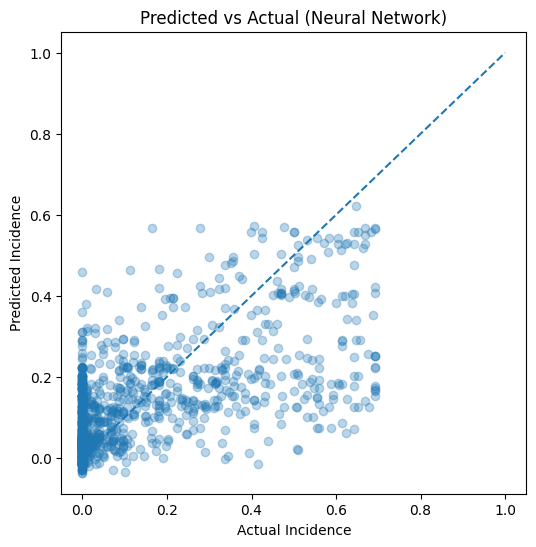

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_nn, alpha=0.3)
plt.plot([0,1], [0,1], '--')
plt.xlabel("Actual Incidence")
plt.ylabel("Predicted Incidence")
plt.title("Predicted vs Actual (Neural Network)")
plt.show()

Clustering

Preparing features

In [28]:
from sklearn.preprocessing import StandardScaler

# features used for clustering
cluster_features = df_clean[["bio01", "bio12", "Incidence"]].dropna()

# scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)

Choosing number of clusters

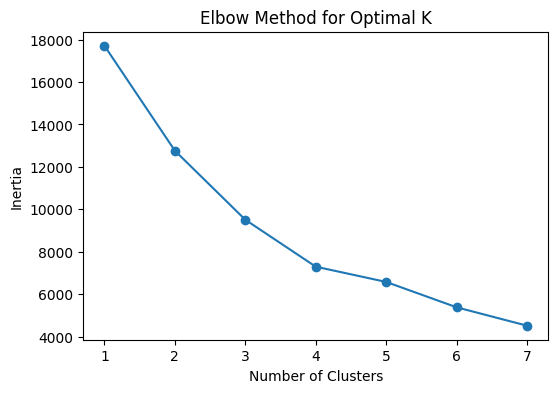

In [29]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))

plt.plot(range(1, 8), inertia, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.show()

Final Clustering model 

In [34]:

kmeans = KMeans(n_clusters=4, random_state=42)

df_clean["cluster"] = kmeans.fit_predict(X_scaled)

Visualization

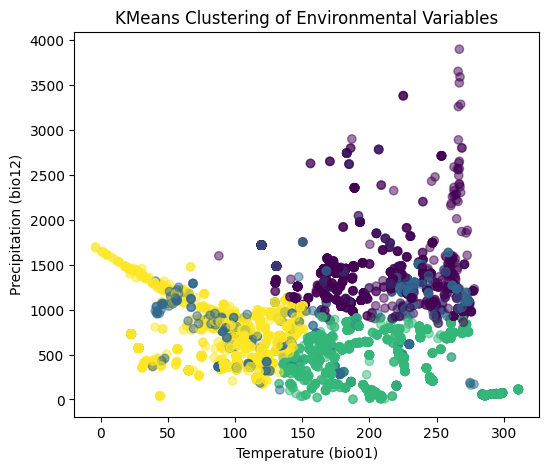

In [35]:
plt.figure(figsize=(6,5))

plt.scatter(
    df_clean["bio01"],
    df_clean["bio12"],
    c=df_clean["cluster"],
    cmap="viridis",
    alpha=0.5
)

plt.xlabel("Temperature (bio01)")
plt.ylabel("Precipitation (bio12)")
plt.title("KMeans Clustering of Environmental Variables")

plt.show()

Interpretation

In [32]:
df_clean.groupby("cluster")[["bio01", "bio12", "Incidence"]].mean()

,bio01,bio12,Incidence
cluster,,,
0,198.439606,1389.890367,0.116022
1,167.732377,870.172812,0.753747
2,192.497563,432.558292,0.056762
3,96.899620,711.029109,0.077949


Interpretation 

Blue: Temp ≈ 200  
      Precip ≈ 1390  
      Incidence ≈ 0.23

Moderate temperature, high precipitation, higher disease incidence
(wetter environments relatively higher infection levels)

Green: Temp ≈ 227  
       Precip ≈ 451  
       ncidence ≈ 0.14

High temperature, low precipitation, lower disease incidence
(hot and dry environments lower infection levels)

Yellow: Temp ≈ 113  
        Precip ≈ 628  
        Incidence ≈ 0.14

Low temperature, moderate precipitation, lower disease incidence
(cooler environments, also lower infection levels)

This suggests:

moisture may play a role in disease spread
but temperature alone is not enough
and overall variability still exists

Feature Importance

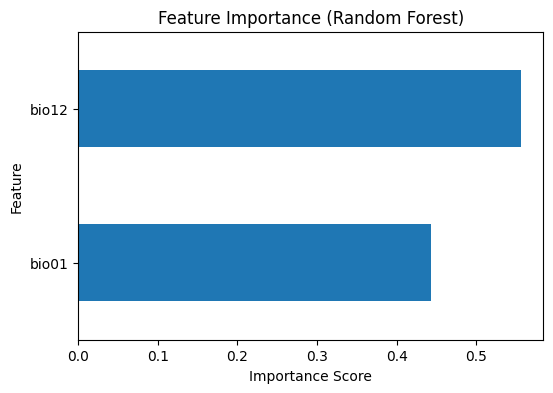

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

importances = rf.feature_importances_
feature_names = X.columns

feat_imp = pd.Series(importances, index=feature_names)

plt.figure(figsize=(6,4))
feat_imp.sort_values().plot(kind='barh')
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

Predicted vs Actual Plot

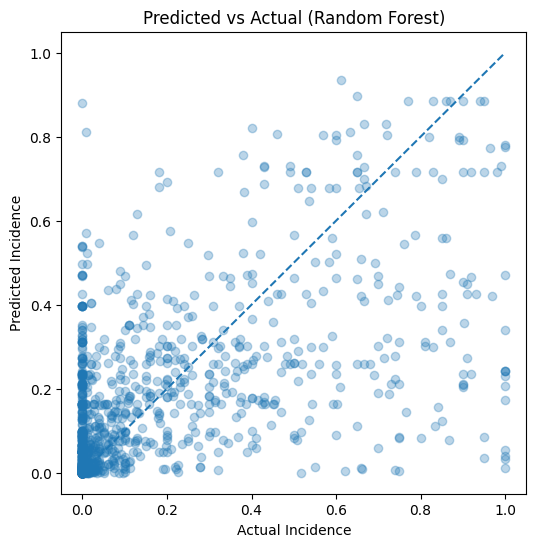

In [10]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_rf, alpha=0.3)

plt.xlabel("Actual Incidence")
plt.ylabel("Predicted Incidence")
plt.title("Predicted vs Actual (Random Forest)")

# perfect prediction line
plt.plot([0,1], [0,1], linestyle='--')

plt.show()

Visualization

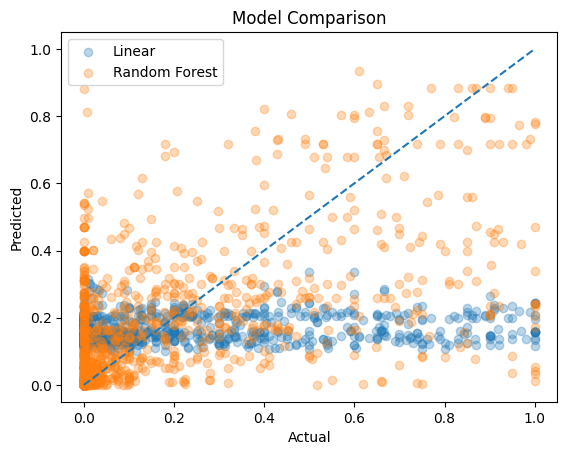

In [11]:
plt.scatter(y_test, y_pred_lr, alpha=0.3, label="Linear")
plt.scatter(y_test, y_pred_rf, alpha=0.3, label="Random Forest")

plt.plot([0,1],[0,1],'--')

plt.legend()
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Model Comparison")

plt.show()